<a href="https://colab.research.google.com/github/IGiovanniRamirez/Giovanni-Ramirez-Data-Portfolio/blob/main/An%C3%A1lisis%20del%20desempe%C3%B1o%20financiero%20/An%C3%A1lisis_del_desempe%C3%B1o_financiero_de_Adventure_Works_con_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis del desempeño financiero de Adventure Works con SQL

## 🟦 1. Introducción
Como analista de datos en AdventureWorks, el objetivo de este proyecto es evaluar el desempeño financiero de la empresa a nivel de país y territorio.

El análisis busca responder dos preguntas clave del director financiero:
- ¿Cuánto estamos ganando por país?
- ¿Qué tan rentable es cada mercado considerando los gastos de marketing?

Para ello, se integran datos de ventas, productos, territorios y campañas de marketing.

## 🟦 2. Objetivos del proyecto

- Navegar un esquema relacional utilizando JOINs
- Limpiar y preparar datos con SQL
- Calcular KPIs financieros:
  - Ingresos
  - Costos
  - Beneficio bruto
  - Margen %
  - ROI %
- Validar la calidad de los datos (QA)
- Comunicar hallazgos mediante un resumen ejecutivo (CFI)

## 🟦 3. Exploración del esquema (SQL)

### 🔹 Vista inicial de tablas


SELECT *                
FROM ventas_2017              
LIMIT 10;

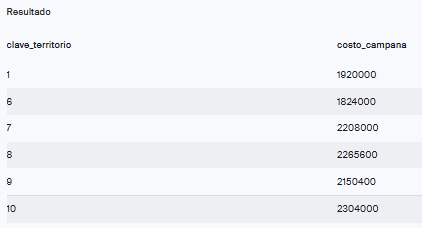




SELECT *                
FROM productos               
LIMIT 10;
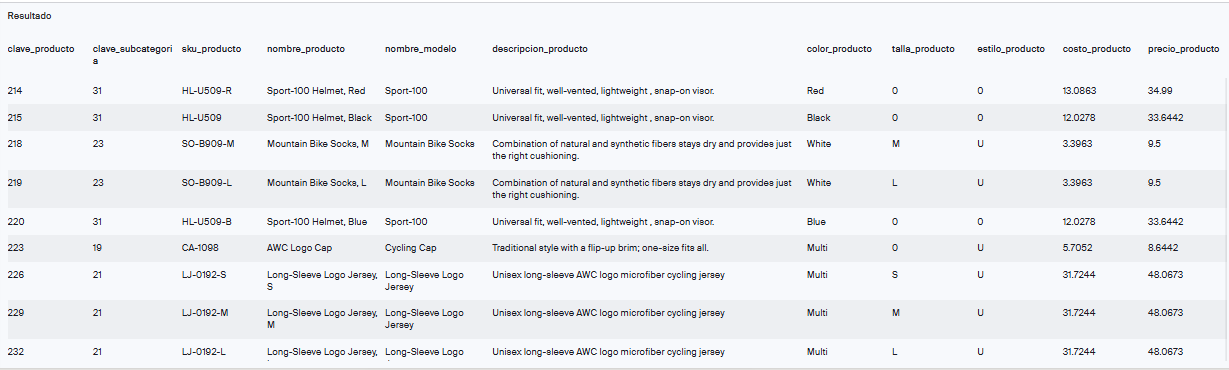

SELECT *                
FROM productos_categorias             
LIMIT 10;
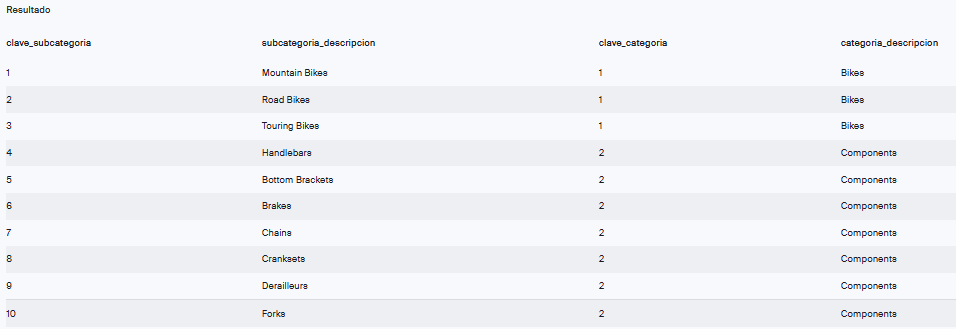

SELECT *                
FROM territorios              
LIMIT 10;

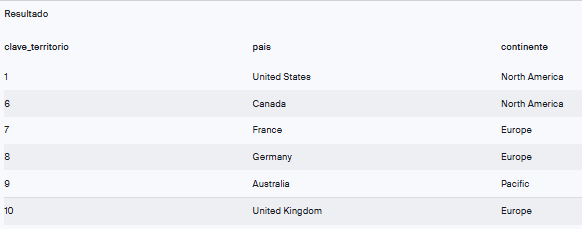

SELECT *                
FROM campanas              
LIMIT 10;

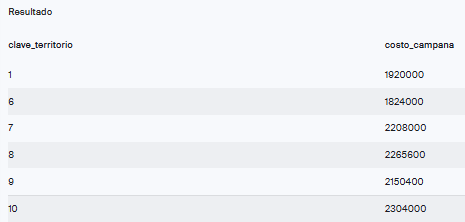

## 🟦 4. Extracción y limpieza de datos

Se construye una tabla base unificada que integra:
- Ventas
- Productos
- Categorías
- Territorios

Se manejan valores nulos con COALESCE y se calculan:
- ingreso_total
- costo_total

## 🟦 5. Construcción de tabla base (SQL)

SELECT
    v.numero_pedido,    
    v.clave_producto,   
    p.nombre_producto,      
    pc.clave_categoria,   
    COALESCE(p.precio_producto, 0) AS precio_producto,  
    COALESCE(v.cantidad_pedido, 0) AS cantidad_pedido,    
    COALESCE(p.costo_producto, 0) AS costo_producto,   
    t.pais,   
    t.continente,     
    v.clave_territorio,     
    precio_producto * cantidad_pedido AS ingreso_total,    
    costo_producto * cantidad_pedido AS costo_total    
FROM ventas_2017 AS v    
JOIN productos AS p   
  ON v.clave_producto = p.clave_producto    
LEFT JOIN productos_categorias AS pc    
  ON p.clave_subcategoria = pc.clave_subcategoria    
LEFT JOIN territorios AS t     
  ON v.clave_territorio = t.clave_territorio;

  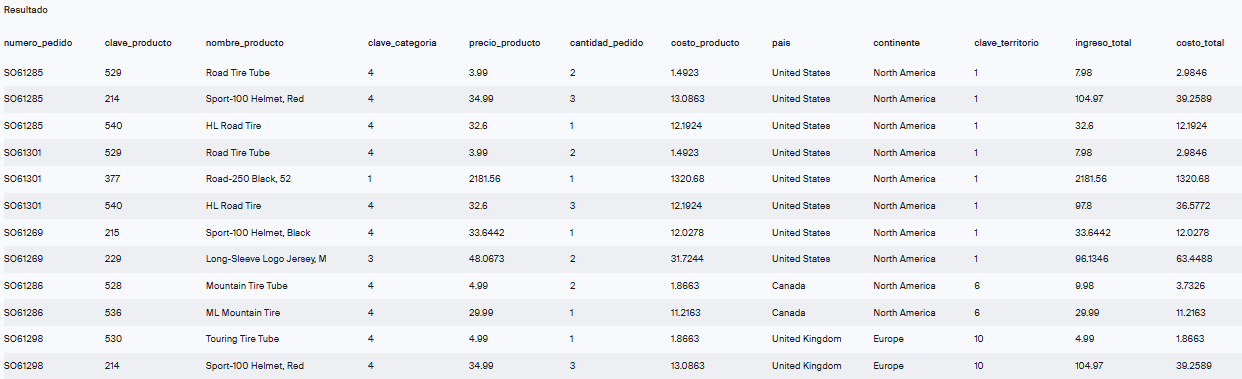

## 🟦 6. Cálculo de KPIs financieros

Se agregan los datos por país y territorio para calcular:

- Ingresos totales
- Costos totales
- Gasto en campañas
- Beneficio bruto
- Margen %
- ROI %

## 🟦 7. KPIs por país (SQL)

SELECT
    p.pais,    
    p.clave_territorio,   
    SUM(p.ingresos)::integer AS ingresos,      
    SUM(p.costos)::integer AS costos,    
    COALESCE(SUM(c.costo_campana::integer), 0) AS costo_campana,      
    (SUM(p.ingresos) - SUM(p.costos))::integer AS beneficio_bruto,     
    (SUM(p.ingresos) - SUM(p.costos)) * 100 / SUM(p.ingresos) AS margen_pct,         
    (SUM(p.ingresos) - SUM(p.costos)) * 100 / NULLIF(SUM(c.costo_campana),0) AS roi_pct       
FROM pais_ingreso_costo AS p       
LEFT JOIN pais_campanas AS c       
  ON p.clave_territorio = c.clave_territorio    
GROUP BY      
    p.pais,      
    p.clave_territorio       
ORDER BY     
    p.clave_territorio, ingresos, costos;

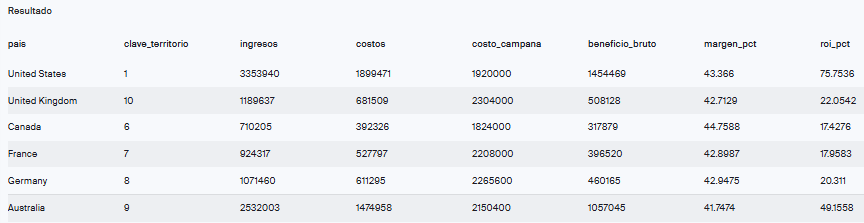

## 🟦 8. Validación de datos (QA)

Se realizan controles para asegurar:
- Ausencia de valores nulos críticos
- Consistencia en cantidades
- Precios válidos

## 🟦 9. Validaciones (SQL)
### 🔹 Nulos en claves

SELECT       
    SUM(CASE WHEN numero_pedido IS NULL THEN 1 ELSE 0 END) AS nulos_numero_pedido,          
    SUM(CASE WHEN clave_producto IS NULL THEN 1 ELSE 0 END) AS nulos_clave_producto,         
    SUM(CASE WHEN clave_territorio IS NULL THEN 1 ELSE 0 END) AS nulos_clave_territorio        
FROM ventas_2017;

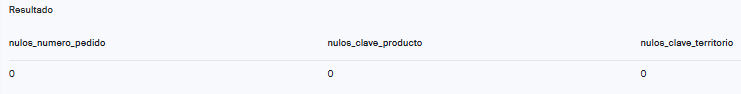

### 🔹 Cantidades no válidas

SELECT         
    COUNT(cantidad_pedido) AS filas_cantidad_no_valida      
FROM ventas_2017       
WHERE cantidad_pedido <= 0;

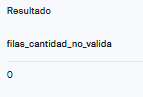

### 🔹 Precios negativos

SELECT      
    COUNT(precio_producto) AS productos_precio_no_valido          
FROM productos         
WHERE precio_producto < 0;

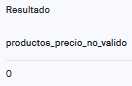

# 🟦 10. Resumen ejecutivo (CFI)

## Contexto
1. Se analizó el desempeño financiero por país y territorio usando datos de ventas, costos operativos y gastos de marketing.
2. Se calcularon ingresos, costos, beneficio bruto, margen y ROI.
3. Se evaluó la eficiencia de las campañas de marketing en cada mercado.

## Hallazgos
1. El país con mejor desempeño es Estados Unidos, con el mayor beneficio bruto y ROI, además de un margen sólido.
2. Francia es el país menos rentable, con bajo ROI, margen y beneficio bruto.
3. Las campañas menos efectivas se observan en Francia, Alemania y Reino Unido, donde el gasto es alto pero el retorno bajo.
4. Canadá presenta un ROI bajo a pesar de no ser el mercado más costoso.

## Implicaciones
1. Incrementar la inversión en países con alto margen y ROI para maximizar el crecimiento.
2. Revisar la efectividad de campañas y estructura de costos en mercados con bajo desempeño.

## 🟦 11. Reflexión final

- El Margen mide qué proporción del ingreso se convierte en beneficio después de costos.
- El ROI mide la eficiencia del gasto en marketing.

El alto ROI en Estados Unidos se explica por un alto beneficio bruto y menor gasto relativo en campañas.

Si el gasto en marketing aumentara un 50%, el ROI disminuiría si las ventas no crecen proporcionalmente.

## 🟦 12. Dashboard (resumen)

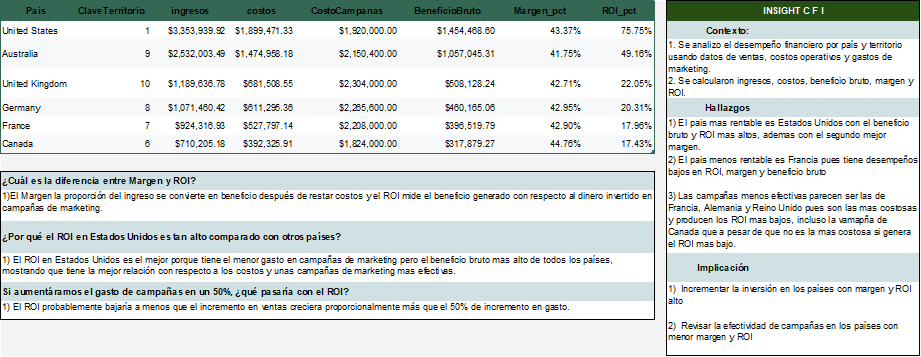